In [2]:
import torch





def binary_accuracy(output, target):
    """
    Computes accuracy for multi-label binary predictions.
    output: probabilities (after sigmoid)
    target: binary labels (0 or 1)
    """
    pred = (output >= 0.5).float()
    correct = (pred == target).float().sum()
    acc = correct / target.numel()
    return acc * 100


binary_accuracy(torch.tensor([[0.8, 0.3], [0.4, 0.6]]), torch.tensor([[1, 0], [0, 1]]))

tensor(100.)

In [ ]:
from dataset import CUBDataset


In [13]:
import pickle
from dataset import CUBDataset
import torchvision.transforms as transforms


pkl_file_paths = ["class_attr_data_10/train.pkl"]
use_attr = True
no_img = False
uncertain_label = False
image_dir = "images/"
n_class_attr = 2
resol=299


transform = transforms.Compose([
        transforms.CenterCrop(resol),
        transforms.ToTensor(), #implicitly divides by 255
        transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [2, 2, 2])
            ])





cub = CUBDataset(pkl_file_paths=pkl_file_paths, use_attr=use_attr, no_img=no_img, uncertain_label=uncertain_label, image_dir=image_dir, n_class_attr=n_class_attr, transform=transform)

In [19]:
from torch.utils.data import DataLoader 
train_loader = DataLoader(cub, batch_size=32, shuffle=True)

i = 0



for data in train_loader:
    inputs, labels, attr_labels = data
    attr_labels = [i.long() for i in attr_labels]
    if i == 0:
        print(len(attr_labels))

    attr_labels = torch.stack(attr_labels).t()#.float() #N x 312
    if i == 0:
        print(attr_labels.shape)

    i += 1




112
torch.Size([32, 112])


In [22]:
a = [2,4,6]
b = [1,3,5]

c = [a]
c.extend(b)
print(c)

[[2, 4, 6], 1, 3, 5]


In [27]:
data = pickle.load(open("Data/class_attr_data_10/train.pkl", "rb"))
print(data[0].keys())
print(data[0]["attribute_label"])

dict_keys(['id', 'img_path', 'class_label', 'attribute_label', 'attribute_certainty'])
[np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np

/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_18171/1571465985.py:1: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(open("Data/class_attr_data_10/train.pkl", "rb"))


In [ ]:
SELECTED_ATTRIBUTED_ORIG_CBM =   [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]


# Check that we have class-level attributes

In [168]:
import pickle 

data = pickle.load(open("Data/class_attr_data_10/test.pkl", "rb"))


class_attributes = {}


for sample in data:
    class_id = sample["class_label"]
    if class_id not in class_attributes:
        class_attributes[class_id] = [sample["attribute_label"]]
    else:
        class_attributes[class_id].append(sample["attribute_label"])

class_attributes = {class_id: np.array(attr_labels)for class_id, attr_labels in class_attributes.items()}
class_attributes_sum = {class_id: np.sum(attr_labels, axis=0) for class_id, attr_labels in class_attributes.items()}
class_num_samples = {class_id: attr_labels.shape[0] for class_id, attr_labels in class_attributes.items()}

print(class_attributes_sum.values())
print(class_num_samples.values())



    
np.unique(class_attributes[class_id], axis=0).shape[0] == 1

/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_12410/2799559589.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(open("Data/class_attr_data_10/test.pkl", "rb"))


dict_values([array([ 0, 30,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       30,  0,  0,  0,  0, 30,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 30,
       30,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 30,  0,  0,  0, 30,  0,
        0, 30,  0,  0, 30,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0]), array([ 0, 30,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 30,  0,  0,  0,
        0,  0,  0, 30,  0, 30,  0,  0, 30,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, 30,  0,  0,  0,  0, 30,  0, 30,
       30,  0,  0,  0,  0,  0,  0, 30,  0,  0, 30,  0,  0,  0,  0,  0,  0,
       30,  0,  0,  0,  0,  0, 30,  0,  0,  0,  0, 30,  0,  0,  0, 30,  0,
        0,  0,  0,  0, 30,  0,  0,  0, 30, 30,  0,  0,  0,  0,  0,  0, 30,
        0,  0,  0,  0,  0, 30, 30,  0,

True

# Compare Mateo and my code for getting correct indices for attribute groups

In [121]:
def get_attribute_parts_to_indices():
    """
    Maps attribute idx to attribute parts (e.g. bill, wing, etc.)
    """
    
    
    # Attribute idx in the original 312 attribute space to attribute idx in the new 112 attribute space
    old_idx_to_new_idx = {old_idx: new_idx for new_idx, old_idx in enumerate(ATTRIBUTES_IDX_USED)}
    #print(old_idx_to_new_idx)
    
    with open(args.data_dir + args.cub_data_dir + "attributes.txt", "r") as f:
        lines = f.readlines()
        semantic_groups = {}
        for line in lines:
            idx, attr_name = line.strip().split(" ")
            idx = int(idx) - 1 # Convert to 0-based index
            if idx not in ATTRIBUTES_IDX_USED:
                continue
                
            new_idx = old_idx_to_new_idx[idx]
            semantic_group = attr_name.split("::")[0]
            if semantic_group not in semantic_groups:
                semantic_groups[semantic_group] = []
            semantic_groups[semantic_group].append(new_idx)
        #print(semantic_groups)
        return semantic_groups
    
   
get_attribute_parts_to_indices()


{'has_bill_shape': [0, 1, 2, 3],
 'has_wing_color': [4, 5, 6, 7, 8, 9],
 'has_upperparts_color': [10, 11, 12, 13, 14, 15],
 'has_underparts_color': [16, 17, 18, 19, 20, 21],
 'has_breast_pattern': [22, 23, 24],
 'has_back_color': [25, 26, 27, 28, 29, 30],
 'has_tail_shape': [31],
 'has_upper_tail_color': [32, 33, 34, 35, 36],
 'has_head_pattern': [37, 38],
 'has_breast_color': [39, 40, 41, 42, 43, 44],
 'has_throat_color': [45, 46, 47, 48, 49],
 'has_eye_color': [50],
 'has_bill_length': [51, 52],
 'has_forehead_color': [53, 54, 55, 56, 57, 58],
 'has_under_tail_color': [59, 60, 61, 62, 63],
 'has_nape_color': [64, 65, 66, 67, 68, 69],
 'has_belly_color': [70, 71, 72, 73, 74, 75],
 'has_wing_shape': [76, 77],
 'has_size': [78, 79, 80],
 'has_shape': [81, 82],
 'has_back_pattern': [83, 84, 85],
 'has_tail_pattern': [86, 87, 88],
 'has_belly_pattern': [89],
 'has_primary_color': [90, 91, 92, 93, 94, 95],
 'has_leg_color': [96, 97, 98],
 'has_bill_color': [99, 100, 101],
 'has_crown_color

In [122]:

import numpy as np

import torchvision.transforms as transforms

from collections import defaultdict



from torch.utils.data import Dataset, DataLoader




#########################################################
## CONCEPT INFORMATION REGARDING CUB
#########################################################

# CUB Class names

CLASS_NAMES = [
    "Black_footed_Albatross",
    "Laysan_Albatross",
    "Sooty_Albatross",
    "Groove_billed_Ani",
    "Crested_Auklet",
    "Least_Auklet",
    "Parakeet_Auklet",
    "Rhinoceros_Auklet",
    "Brewer_Blackbird",
    "Red_winged_Blackbird",
    "Rusty_Blackbird",
    "Yellow_headed_Blackbird",
    "Bobolink",
    "Indigo_Bunting",
    "Lazuli_Bunting",
    "Painted_Bunting",
    "Cardinal",
    "Spotted_Catbird",
    "Gray_Catbird",
    "Yellow_breasted_Chat",
    "Eastern_Towhee",
    "Chuck_will_Widow",
    "Brandt_Cormorant",
    "Red_faced_Cormorant",
    "Pelagic_Cormorant",
    "Bronzed_Cowbird",
    "Shiny_Cowbird",
    "Brown_Creeper",
    "American_Crow",
    "Fish_Crow",
    "Black_billed_Cuckoo",
    "Mangrove_Cuckoo",
    "Yellow_billed_Cuckoo",
    "Gray_crowned_Rosy_Finch",
    "Purple_Finch",
    "Northern_Flicker",
    "Acadian_Flycatcher",
    "Great_Crested_Flycatcher",
    "Least_Flycatcher",
    "Olive_sided_Flycatcher",
    "Scissor_tailed_Flycatcher",
    "Vermilion_Flycatcher",
    "Yellow_bellied_Flycatcher",
    "Frigatebird",
    "Northern_Fulmar",
    "Gadwall",
    "American_Goldfinch",
    "European_Goldfinch",
    "Boat_tailed_Grackle",
    "Eared_Grebe",
    "Horned_Grebe",
    "Pied_billed_Grebe",
    "Western_Grebe",
    "Blue_Grosbeak",
    "Evening_Grosbeak",
    "Pine_Grosbeak",
    "Rose_breasted_Grosbeak",
    "Pigeon_Guillemot",
    "California_Gull",
    "Glaucous_winged_Gull",
    "Heermann_Gull",
    "Herring_Gull",
    "Ivory_Gull",
    "Ring_billed_Gull",
    "Slaty_backed_Gull",
    "Western_Gull",
    "Anna_Hummingbird",
    "Ruby_throated_Hummingbird",
    "Rufous_Hummingbird",
    "Green_Violetear",
    "Long_tailed_Jaeger",
    "Pomarine_Jaeger",
    "Blue_Jay",
    "Florida_Jay",
    "Green_Jay",
    "Dark_eyed_Junco",
    "Tropical_Kingbird",
    "Gray_Kingbird",
    "Belted_Kingfisher",
    "Green_Kingfisher",
    "Pied_Kingfisher",
    "Ringed_Kingfisher",
    "White_breasted_Kingfisher",
    "Red_legged_Kittiwake",
    "Horned_Lark",
    "Pacific_Loon",
    "Mallard",
    "Western_Meadowlark",
    "Hooded_Merganser",
    "Red_breasted_Merganser",
    "Mockingbird",
    "Nighthawk",
    "Clark_Nutcracker",
    "White_breasted_Nuthatch",
    "Baltimore_Oriole",
    "Hooded_Oriole",
    "Orchard_Oriole",
    "Scott_Oriole",
    "Ovenbird",
    "Brown_Pelican",
    "White_Pelican",
    "Western_Wood_Pewee",
    "Sayornis",
    "American_Pipit",
    "Whip_poor_Will",
    "Horned_Puffin",
    "Common_Raven",
    "White_necked_Raven",
    "American_Redstart",
    "Geococcyx",
    "Loggerhead_Shrike",
    "Great_Grey_Shrike",
    "Baird_Sparrow",
    "Black_throated_Sparrow",
    "Brewer_Sparrow",
    "Chipping_Sparrow",
    "Clay_colored_Sparrow",
    "House_Sparrow",
    "Field_Sparrow",
    "Fox_Sparrow",
    "Grasshopper_Sparrow",
    "Harris_Sparrow",
    "Henslow_Sparrow",
    "Le_Conte_Sparrow",
    "Lincoln_Sparrow",
    "Nelson_Sharp_tailed_Sparrow",
    "Savannah_Sparrow",
    "Seaside_Sparrow",
    "Song_Sparrow",
    "Tree_Sparrow",
    "Vesper_Sparrow",
    "White_crowned_Sparrow",
    "White_throated_Sparrow",
    "Cape_Glossy_Starling",
    "Bank_Swallow",
    "Barn_Swallow",
    "Cliff_Swallow",
    "Tree_Swallow",
    "Scarlet_Tanager",
    "Summer_Tanager",
    "Artic_Tern",
    "Black_Tern",
    "Caspian_Tern",
    "Common_Tern",
    "Elegant_Tern",
    "Forsters_Tern",
    "Least_Tern",
    "Green_tailed_Towhee",
    "Brown_Thrasher",
    "Sage_Thrasher",
    "Black_capped_Vireo",
    "Blue_headed_Vireo",
    "Philadelphia_Vireo",
    "Red_eyed_Vireo",
    "Warbling_Vireo",
    "White_eyed_Vireo",
    "Yellow_throated_Vireo",
    "Bay_breasted_Warbler",
    "Black_and_white_Warbler",
    "Black_throated_Blue_Warbler",
    "Blue_winged_Warbler",
    "Canada_Warbler",
    "Cape_May_Warbler",
    "Cerulean_Warbler",
    "Chestnut_sided_Warbler",
    "Golden_winged_Warbler",
    "Hooded_Warbler",
    "Kentucky_Warbler",
    "Magnolia_Warbler",
    "Mourning_Warbler",
    "Myrtle_Warbler",
    "Nashville_Warbler",
    "Orange_crowned_Warbler",
    "Palm_Warbler",
    "Pine_Warbler",
    "Prairie_Warbler",
    "Prothonotary_Warbler",
    "Swainson_Warbler",
    "Tennessee_Warbler",
    "Wilson_Warbler",
    "Worm_eating_Warbler",
    "Yellow_Warbler",
    "Northern_Waterthrush",
    "Louisiana_Waterthrush",
    "Bohemian_Waxwing",
    "Cedar_Waxwing",
    "American_Three_toed_Woodpecker",
    "Pileated_Woodpecker",
    "Red_bellied_Woodpecker",
    "Red_cockaded_Woodpecker",
    "Red_headed_Woodpecker",
    "Downy_Woodpecker",
    "Bewick_Wren",
    "Cactus_Wren",
    "Carolina_Wren",
    "House_Wren",
    "Marsh_Wren",
    "Rock_Wren",
    "Winter_Wren",
    "Common_Yellowthroat",
]
# Set of CUB attributes selected by original CBM paper
SELECTED_CONCEPTS = [
    1,
    4,
    6,
    7,
    10,
    14,
    15,
    20,
    21,
    23,
    25,
    29,
    30,
    35,
    36,
    38,
    40,
    44,
    45,
    50,
    51,
    53,
    54,
    56,
    57,
    59,
    63,
    64,
    69,
    70,
    72,
    75,
    80,
    84,
    90,
    91,
    93,
    99,
    101,
    106,
    110,
    111,
    116,
    117,
    119,
    125,
    126,
    131,
    132,
    134,
    145,
    149,
    151,
    152,
    153,
    157,
    158,
    163,
    164,
    168,
    172,
    178,
    179,
    181,
    183,
    187,
    188,
    193,
    194,
    196,
    198,
    202,
    203,
    208,
    209,
    211,
    212,
    213,
    218,
    220,
    221,
    225,
    235,
    236,
    238,
    239,
    240,
    242,
    243,
    244,
    249,
    253,
    254,
    259,
    260,
    262,
    268,
    274,
    277,
    283,
    289,
    292,
    293,
    294,
    298,
    299,
    304,
    305,
    308,
    309,
    310,
    311,
]

# Names of all CUB attributes
CONCEPT_SEMANTICS = [
    "has_bill_shape::curved_(up_or_down)",
    "has_bill_shape::dagger",
    "has_bill_shape::hooked",
    "has_bill_shape::needle",
    "has_bill_shape::hooked_seabird",
    "has_bill_shape::spatulate",
    "has_bill_shape::all-purpose",
    "has_bill_shape::cone",
    "has_bill_shape::specialized",
    "has_wing_color::blue",
    "has_wing_color::brown",
    "has_wing_color::iridescent",
    "has_wing_color::purple",
    "has_wing_color::rufous",
    "has_wing_color::grey",
    "has_wing_color::yellow",
    "has_wing_color::olive",
    "has_wing_color::green",
    "has_wing_color::pink",
    "has_wing_color::orange",
    "has_wing_color::black",
    "has_wing_color::white",
    "has_wing_color::red",
    "has_wing_color::buff",
    "has_upperparts_color::blue",
    "has_upperparts_color::brown",
    "has_upperparts_color::iridescent",
    "has_upperparts_color::purple",
    "has_upperparts_color::rufous",
    "has_upperparts_color::grey",
    "has_upperparts_color::yellow",
    "has_upperparts_color::olive",
    "has_upperparts_color::green",
    "has_upperparts_color::pink",
    "has_upperparts_color::orange",
    "has_upperparts_color::black",
    "has_upperparts_color::white",
    "has_upperparts_color::red",
    "has_upperparts_color::buff",
    "has_underparts_color::blue",
    "has_underparts_color::brown",
    "has_underparts_color::iridescent",
    "has_underparts_color::purple",
    "has_underparts_color::rufous",
    "has_underparts_color::grey",
    "has_underparts_color::yellow",
    "has_underparts_color::olive",
    "has_underparts_color::green",
    "has_underparts_color::pink",
    "has_underparts_color::orange",
    "has_underparts_color::black",
    "has_underparts_color::white",
    "has_underparts_color::red",
    "has_underparts_color::buff",
    "has_breast_pattern::solid",
    "has_breast_pattern::spotted",
    "has_breast_pattern::striped",
    "has_breast_pattern::multi-colored",
    "has_back_color::blue",
    "has_back_color::brown",
    "has_back_color::iridescent",
    "has_back_color::purple",
    "has_back_color::rufous",
    "has_back_color::grey",
    "has_back_color::yellow",
    "has_back_color::olive",
    "has_back_color::green",
    "has_back_color::pink",
    "has_back_color::orange",
    "has_back_color::black",
    "has_back_color::white",
    "has_back_color::red",
    "has_back_color::buff",
    "has_tail_shape::forked_tail",
    "has_tail_shape::rounded_tail",
    "has_tail_shape::notched_tail",
    "has_tail_shape::fan-shaped_tail",
    "has_tail_shape::pointed_tail",
    "has_tail_shape::squared_tail",
    "has_upper_tail_color::blue",
    "has_upper_tail_color::brown",
    "has_upper_tail_color::iridescent",
    "has_upper_tail_color::purple",
    "has_upper_tail_color::rufous",
    "has_upper_tail_color::grey",
    "has_upper_tail_color::yellow",
    "has_upper_tail_color::olive",
    "has_upper_tail_color::green",
    "has_upper_tail_color::pink",
    "has_upper_tail_color::orange",
    "has_upper_tail_color::black",
    "has_upper_tail_color::white",
    "has_upper_tail_color::red",
    "has_upper_tail_color::buff",
    "has_head_pattern::spotted",
    "has_head_pattern::malar",
    "has_head_pattern::crested",
    "has_head_pattern::masked",
    "has_head_pattern::unique_pattern",
    "has_head_pattern::eyebrow",
    "has_head_pattern::eyering",
    "has_head_pattern::plain",
    "has_head_pattern::eyeline",
    "has_head_pattern::striped",
    "has_head_pattern::capped",
    "has_breast_color::blue",
    "has_breast_color::brown",
    "has_breast_color::iridescent",
    "has_breast_color::purple",
    "has_breast_color::rufous",
    "has_breast_color::grey",
    "has_breast_color::yellow",
    "has_breast_color::olive",
    "has_breast_color::green",
    "has_breast_color::pink",
    "has_breast_color::orange",
    "has_breast_color::black",
    "has_breast_color::white",
    "has_breast_color::red",
    "has_breast_color::buff",
    "has_throat_color::blue",
    "has_throat_color::brown",
    "has_throat_color::iridescent",
    "has_throat_color::purple",
    "has_throat_color::rufous",
    "has_throat_color::grey",
    "has_throat_color::yellow",
    "has_throat_color::olive",
    "has_throat_color::green",
    "has_throat_color::pink",
    "has_throat_color::orange",
    "has_throat_color::black",
    "has_throat_color::white",
    "has_throat_color::red",
    "has_throat_color::buff",
    "has_eye_color::blue",
    "has_eye_color::brown",
    "has_eye_color::purple",
    "has_eye_color::rufous",
    "has_eye_color::grey",
    "has_eye_color::yellow",
    "has_eye_color::olive",
    "has_eye_color::green",
    "has_eye_color::pink",
    "has_eye_color::orange",
    "has_eye_color::black",
    "has_eye_color::white",
    "has_eye_color::red",
    "has_eye_color::buff",
    "has_bill_length::about_the_same_as_head",
    "has_bill_length::longer_than_head",
    "has_bill_length::shorter_than_head",
    "has_forehead_color::blue",
    "has_forehead_color::brown",
    "has_forehead_color::iridescent",
    "has_forehead_color::purple",
    "has_forehead_color::rufous",
    "has_forehead_color::grey",
    "has_forehead_color::yellow",
    "has_forehead_color::olive",
    "has_forehead_color::green",
    "has_forehead_color::pink",
    "has_forehead_color::orange",
    "has_forehead_color::black",
    "has_forehead_color::white",
    "has_forehead_color::red",
    "has_forehead_color::buff",
    "has_under_tail_color::blue",
    "has_under_tail_color::brown",
    "has_under_tail_color::iridescent",
    "has_under_tail_color::purple",
    "has_under_tail_color::rufous",
    "has_under_tail_color::grey",
    "has_under_tail_color::yellow",
    "has_under_tail_color::olive",
    "has_under_tail_color::green",
    "has_under_tail_color::pink",
    "has_under_tail_color::orange",
    "has_under_tail_color::black",
    "has_under_tail_color::white",
    "has_under_tail_color::red",
    "has_under_tail_color::buff",
    "has_nape_color::blue",
    "has_nape_color::brown",
    "has_nape_color::iridescent",
    "has_nape_color::purple",
    "has_nape_color::rufous",
    "has_nape_color::grey",
    "has_nape_color::yellow",
    "has_nape_color::olive",
    "has_nape_color::green",
    "has_nape_color::pink",
    "has_nape_color::orange",
    "has_nape_color::black",
    "has_nape_color::white",
    "has_nape_color::red",
    "has_nape_color::buff",
    "has_belly_color::blue",
    "has_belly_color::brown",
    "has_belly_color::iridescent",
    "has_belly_color::purple",
    "has_belly_color::rufous",
    "has_belly_color::grey",
    "has_belly_color::yellow",
    "has_belly_color::olive",
    "has_belly_color::green",
    "has_belly_color::pink",
    "has_belly_color::orange",
    "has_belly_color::black",
    "has_belly_color::white",
    "has_belly_color::red",
    "has_belly_color::buff",
    "has_wing_shape::rounded-wings",
    "has_wing_shape::pointed-wings",
    "has_wing_shape::broad-wings",
    "has_wing_shape::tapered-wings",
    "has_wing_shape::long-wings",
    "has_size::large_(16_-_32_in)",
    "has_size::small_(5_-_9_in)",
    "has_size::very_large_(32_-_72_in)",
    "has_size::medium_(9_-_16_in)",
    "has_size::very_small_(3_-_5_in)",
    "has_shape::upright-perching_water-like",
    "has_shape::chicken-like-marsh",
    "has_shape::long-legged-like",
    "has_shape::duck-like",
    "has_shape::owl-like",
    "has_shape::gull-like",
    "has_shape::hummingbird-like",
    "has_shape::pigeon-like",
    "has_shape::tree-clinging-like",
    "has_shape::hawk-like",
    "has_shape::sandpiper-like",
    "has_shape::upland-ground-like",
    "has_shape::swallow-like",
    "has_shape::perching-like",
    "has_back_pattern::solid",
    "has_back_pattern::spotted",
    "has_back_pattern::striped",
    "has_back_pattern::multi-colored",
    "has_tail_pattern::solid",
    "has_tail_pattern::spotted",
    "has_tail_pattern::striped",
    "has_tail_pattern::multi-colored",
    "has_belly_pattern::solid",
    "has_belly_pattern::spotted",
    "has_belly_pattern::striped",
    "has_belly_pattern::multi-colored",
    "has_primary_color::blue",
    "has_primary_color::brown",
    "has_primary_color::iridescent",
    "has_primary_color::purple",
    "has_primary_color::rufous",
    "has_primary_color::grey",
    "has_primary_color::yellow",
    "has_primary_color::olive",
    "has_primary_color::green",
    "has_primary_color::pink",
    "has_primary_color::orange",
    "has_primary_color::black",
    "has_primary_color::white",
    "has_primary_color::red",
    "has_primary_color::buff",
    "has_leg_color::blue",
    "has_leg_color::brown",
    "has_leg_color::iridescent",
    "has_leg_color::purple",
    "has_leg_color::rufous",
    "has_leg_color::grey",
    "has_leg_color::yellow",
    "has_leg_color::olive",
    "has_leg_color::green",
    "has_leg_color::pink",
    "has_leg_color::orange",
    "has_leg_color::black",
    "has_leg_color::white",
    "has_leg_color::red",
    "has_leg_color::buff",
    "has_bill_color::blue",
    "has_bill_color::brown",
    "has_bill_color::iridescent",
    "has_bill_color::purple",
    "has_bill_color::rufous",
    "has_bill_color::grey",
    "has_bill_color::yellow",
    "has_bill_color::olive",
    "has_bill_color::green",
    "has_bill_color::pink",
    "has_bill_color::orange",
    "has_bill_color::black",
    "has_bill_color::white",
    "has_bill_color::red",
    "has_bill_color::buff",
    "has_crown_color::blue",
    "has_crown_color::brown",
    "has_crown_color::iridescent",
    "has_crown_color::purple",
    "has_crown_color::rufous",
    "has_crown_color::grey",
    "has_crown_color::yellow",
    "has_crown_color::olive",
    "has_crown_color::green",
    "has_crown_color::pink",
    "has_crown_color::orange",
    "has_crown_color::black",
    "has_crown_color::white",
    "has_crown_color::red",
    "has_crown_color::buff",
    "has_wing_pattern::solid",
    "has_wing_pattern::spotted",
    "has_wing_pattern::striped",
    "has_wing_pattern::multi-colored",
]

# Generate a mapping containing all concept groups in CUB generated
# using a simple prefix tree



CONCEPT_GROUP_MAP = defaultdict(list)
for i, concept_name in enumerate(list(
    np.array(CONCEPT_SEMANTICS)[SELECTED_CONCEPTS]
)):
    group = concept_name[:concept_name.find("::")]
    CONCEPT_GROUP_MAP[group].append(i)


for group, concept_indices in CONCEPT_GROUP_MAP.items():
    print(f"{group}: {concept_indices}")


has_bill_shape: [0, 1, 2, 3]
has_wing_color: [4, 5, 6, 7, 8, 9]
has_upperparts_color: [10, 11, 12, 13, 14, 15]
has_underparts_color: [16, 17, 18, 19, 20, 21]
has_breast_pattern: [22, 23, 24]
has_back_color: [25, 26, 27, 28, 29, 30]
has_tail_shape: [31]
has_upper_tail_color: [32, 33, 34, 35, 36]
has_head_pattern: [37, 38]
has_breast_color: [39, 40, 41, 42, 43, 44]
has_throat_color: [45, 46, 47, 48, 49]
has_eye_color: [50]
has_bill_length: [51, 52]
has_forehead_color: [53, 54, 55, 56, 57, 58]
has_under_tail_color: [59, 60, 61, 62, 63]
has_nape_color: [64, 65, 66, 67, 68, 69]
has_belly_color: [70, 71, 72, 73, 74, 75]
has_wing_shape: [76, 77]
has_size: [78, 79, 80]
has_shape: [81, 82]
has_back_pattern: [83, 84, 85]
has_tail_pattern: [86, 87, 88]
has_belly_pattern: [89]
has_primary_color: [90, 91, 92, 93, 94, 95]
has_leg_color: [96, 97, 98]
has_bill_color: [99, 100, 101]
has_crown_color: [102, 103, 104, 105, 106, 107]
has_wing_pattern: [108, 109, 110, 111]


In [120]:
from models import ModelXtoCtoY
from config import N_CLASSES
from dataset import load_data

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:    
    device = torch.device("cpu")




model = ModelXtoCtoY(
            n_class_attr=2,
            pretrained=False,
            num_classes=N_CLASSES,
            n_attributes=112,
            use_relu=False,
            use_sigmoid=False
        )

state_dict = torch.load("Logs/lr_0.01_wd_4e-05_step_10_bs_64/best_model_Joint.pt", map_location=device)
model = model.to(device)
model.load_state_dict(state_dict)

loader = load_data(["Data/class_attr_data_10/test.pkl"], True, False, 64, image_dir=None,
                       n_class_attr=2)

with torch.no_grad():
    for data in loader:
        inputs, labels, attr_labels = data
        inputs = inputs.to(device)

        full_class_outputs, _ = model(inputs)
        attr_logits = model.first_model(inputs)
        split_class_outputs, _ = model.forward_stage2(attr_logits)

        print("max diff:", (full_class_outputs - split_class_outputs).abs().max().item())
        
    

max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max diff: 0.0
max di

# Check if intervention does what is intended

In [123]:
from dataset import load_data
from models import ModelXtoCtoY
import torch


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:    
    device = torch.device("cpu")    

model = ModelXtoCtoY(
            n_class_attr=2,
            pretrained=False,
            num_classes=N_CLASSES,
            n_attributes=112,
            use_relu=False,
            use_sigmoid=False
        )

state_dict = torch.load("Logs/lr_0.01_wd_4e-05_step_10_bs_64/best_model_Joint.pt", map_location=device)
model = model.to(device)
model.load_state_dict(state_dict)

loader = load_data(["Data/class_attr_data_10/test.pkl"], True, False, 64, image_dir=None,
                       n_class_attr=2)


def compute_concept_percentiles(model, loader):
    model.eval()
    all_attr_outputs = []

    with torch.no_grad():
        for data in loader:
            inputs, labels, attr_labels = data
            inputs = inputs.to(device)

            attr_outputs = model.first_model(inputs)


            all_attr_outputs.append(attr_outputs.detach().cpu().numpy())

    all_attr_outputs = np.concatenate(all_attr_outputs, axis=0)  # (N, A)
    print(f"Shape of all_attr_outputs: {all_attr_outputs.shape}")
    ptl_5 = np.percentile(all_attr_outputs, 5, axis=0)
    ptl_95 = np.percentile(all_attr_outputs, 95, axis=0)
    return ptl_5, ptl_95


ptl_5, ptl_95 = compute_concept_percentiles(model, loader)
ptl_5 = torch.tensor(ptl_5, device=device)
ptl_95 = torch.tensor(ptl_95, device=device)

print(ptl_5.shape, ptl_95.shape)


/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/CBM_Implementation/cbm_implementation_venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/CBM_Implementation/cbm_implementation_venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/CBM_Implementation/dataset.py:80: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  self.data.extend(pickle.load(open(fi

Shape of all_attr_outputs: (5794, 112)
torch.Size([112]) torch.Size([112])


In [126]:
all_attr_outputs = []
all_attr_labels = []
for i, data in enumerate(loader):
    inputs, labels, attr_labels = data

    inputs = inputs.to(device)
    labels = labels.to(device)

    # Convert attr_labels to tensor if it's a list or numpy array
    attr_labels = torch.stack(attr_labels, dim=1)
    #print(f"attr_labels shape: {attr_labels.shape}, inputs shape: {inputs.shape}, labels shape:  {labels.shape}")

    attr_labels = attr_labels.to(device)

    with torch.no_grad():
        attr_outputs = model.first_model(inputs)
    all_attr_outputs.append(attr_outputs)
    all_attr_labels.append(attr_labels)
all_attr_outputs = torch.cat(all_attr_outputs, dim=0)  # (N, A)
all_attr_labels = torch.cat(all_attr_labels, dim=0)  # (N, A)
print(f"Shape of all_attr_outputs: {all_attr_outputs.shape}")
print(f"Shape of all_attr_labels: {all_attr_labels.shape}")

Shape of all_attr_outputs: torch.Size([5794, 112])
Shape of all_attr_labels: torch.Size([5794, 112])


In [132]:
from dataset import DATA_DIR, PKL_FILE_DIR
from utils_intervention import ATTRIBUTES_IDX_USED



intervene_idx = [0, 10, 25]  
use_invisible = True
selected_concepts_zero_based = torch.tensor([idx - 1 for idx in ATTRIBUTES_IDX_USED])

all_attr_certainty = []
test_data = pickle.load(open(args.data_dir + args.pkl_file_dir + "test" + ".pkl", "rb"))
for sample in test_data:
    attribute_certainty_kept = torch.tensor(sample['attribute_certainty'])[selected_concepts_zero_based]
    all_attr_certainty.append(attribute_certainty_kept)
    #print(type(attribute_certainty_kept), len(attribute_certainty_kept))

all_attr_certainty = torch.stack(all_attr_certainty)

attr_new = all_attr_outputs.clone()
B = all_attr_outputs.shape[0]
for i in range(B):
    for a in intervene_idx:
        print(f"Intervening on attribute index: {a}")
        print(f"5th percentile for attribute {a}: {ptl_5[a].item()}, 95th percentile for attribute {a}: {ptl_95[a].item()}")
        binary_val = all_attr_labels[i, a].item()
        print(binary_val)
        # if attribute is "not visible", force intervention target to 0
        if use_invisible and all_attr_certainty is not None and all_attr_certainty[i, a] == 1:
            binary_val = 0
        if binary_val == 1:
            print("yppp")
            attr_new[i, a] = ptl_95[a]
        else:
            attr_new[i, a] = ptl_5[a]
        
    

/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_12410/2164733654.py:6: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  test_data = pickle.load(open(DATA_DIR + PKL_FILE_DIR + "test" + ".pkl", "rb"))


Intervening on attribute index: 0
5th percentile for attribute 0: -3.2394843101501465, 95th percentile for attribute 0: 3.2763617038726807
0
Intervening on attribute index: 10
5th percentile for attribute 10: -4.058013916015625, 95th percentile for attribute 10: 4.568256855010986
0
Intervening on attribute index: 25
5th percentile for attribute 25: -3.503939628601074, 95th percentile for attribute 25: 3.630014657974243
0
Intervening on attribute index: 0
5th percentile for attribute 0: -3.2394843101501465, 95th percentile for attribute 0: 3.2763617038726807
0
Intervening on attribute index: 10
5th percentile for attribute 10: -4.058013916015625, 95th percentile for attribute 10: 4.568256855010986
0
Intervening on attribute index: 25
5th percentile for attribute 25: -3.503939628601074, 95th percentile for attribute 25: 3.630014657974243
0
Intervening on attribute index: 0
5th percentile for attribute 0: -3.2394843101501465, 95th percentile for attribute 0: 3.2763617038726807
0
Interveni

In [ ]:
import pandas as pd
attr_new_relevant = attr_new[:, intervene_idx]

df_attr_new_relevant = pd.DataFrame(attr_new_relevant.cpu().numpy())
df_attr_new_relevant.head()

all_attr_labels_relevant = all_attr_labels[:, intervene_idx]
df_attr_labels_relevant = pd.DataFrame(all_attr_labels_relevant.cpu().numpy())
df_attr_labels_relevant.head()

new_df = pd.concat([df_attr_new_relevant, df_attr_labels_relevant], axis=1)
new_df.to_csv("Data/intervened_attributes.csv", index=False, header=False)

# Intervention sequential model

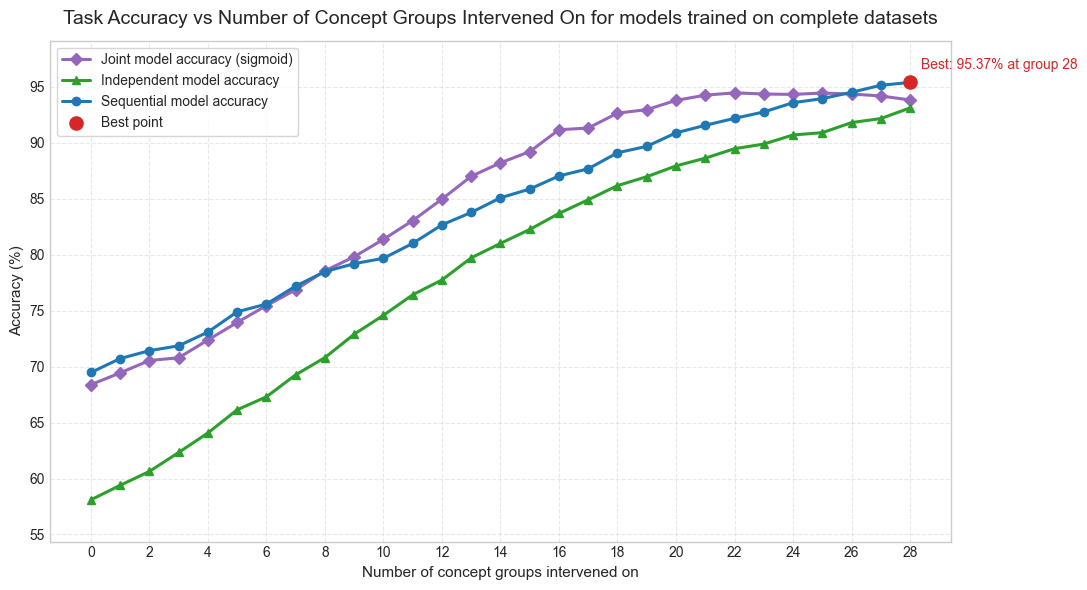

In [91]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

accuracies_sequential = []
accuracies_joint = []
accuracies_independent = []
accuracies_joint_sigmoid = []

with open("intervention/intervene_range_sequential.txt", "r") as f:
    lines = f.readlines()
    for idx, line in enumerate(lines):
        if idx == 0:
            continue
        accuracy = line.strip().split(": ")[1]
        accuracy = float(accuracy)
        accuracies_sequential.append(accuracy)


with open("intervention/intervene_independent_range.txt", "r") as f:
    lines = f.readlines()
    for idx, line in enumerate(lines):
        if idx == 0:
            continue
        accuracy = line.strip().split(": ")[1]
        accuracy = float(accuracy)
        accuracies_independent.append(accuracy)
        
with open("intervention/joint_model_attr_weight_0.01_200_weight_sigmoid_range.txt", "r") as f:
    lines = f.readlines()
    for idx, line in enumerate(lines):
        if idx == 0:
            continue
        accuracy = line.strip().split(": ")[1]
        accuracy = float(accuracy)
        accuracies_joint_sigmoid.append(accuracy)


x = list(range(len(accuracies_sequential)))
best_idx = max(x, key=lambda i: accuracies_sequential[i])
best_acc = accuracies_sequential[best_idx]

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    x,
    accuracies_joint_sigmoid,
    marker="D",
    linewidth=2.2,
    markersize=6,
    color="#9467bd",
    label="Joint model accuracy (sigmoid)",)     




ax.plot(
    x,
    accuracies_independent,
    marker="^",
    linewidth=2.2,
    markersize=6,
    color="#2ca02c",
    label="Independent model accuracy",)

ax.plot(
    x,
    accuracies_sequential,
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#1f77b4",
    label="Sequential model accuracy",
)

ax.scatter([best_idx], [best_acc], color="#d62728", s=90, zorder=3, label="Best point")
ax.annotate(
    f"Best: {best_acc:.2f}% at group {best_idx}",
    xy=(best_idx, best_acc),
    xytext=(8, 10),
    textcoords="offset points",
    fontsize=10,
    color="#d62728",
)
"""
ax.plot(
    x,
    accuracies_joint,
    marker="s",
    linewidth=2.2,
    markersize=6,
    color="#ff7f0e",
    label="Joint intervention accuracy",
)
"""

ax.set_title("Task Accuracy vs Number of Concept Groups Intervened On for models trained on complete datasets", fontsize=14, pad=12)
ax.set_xlabel("Number of concept groups intervened on", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)

# Keep integer ticks but avoid overcrowding if there are many points.
ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune=None, nbins=20))

# Add a little vertical breathing room around the data.
y_min_sequential, y_max_sequential = min(accuracies_sequential), max(accuracies_sequential)
y_min_joint, y_max_joint = min(accuracies_joint_sigmoid), max(accuracies_joint_sigmoid)
y_min_independent, y_max_independent = min(accuracies_independent), max(accuracies_independent)
y_min = min(y_min_sequential, y_min_joint, y_min_independent)
y_max = max(y_max_sequential, y_max_joint, y_max_independent)
pad = max((y_max - y_min) * 0.1, 0.5)
ax.set_ylim(y_min - pad, y_max + pad)

ax.grid(True, which="major", linestyle="--", alpha=0.45)
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

Length of 0.25 list: 22
Length of 0.5 list: 15
Length of 0.75 list: 8
length complete concept dataset list: 29


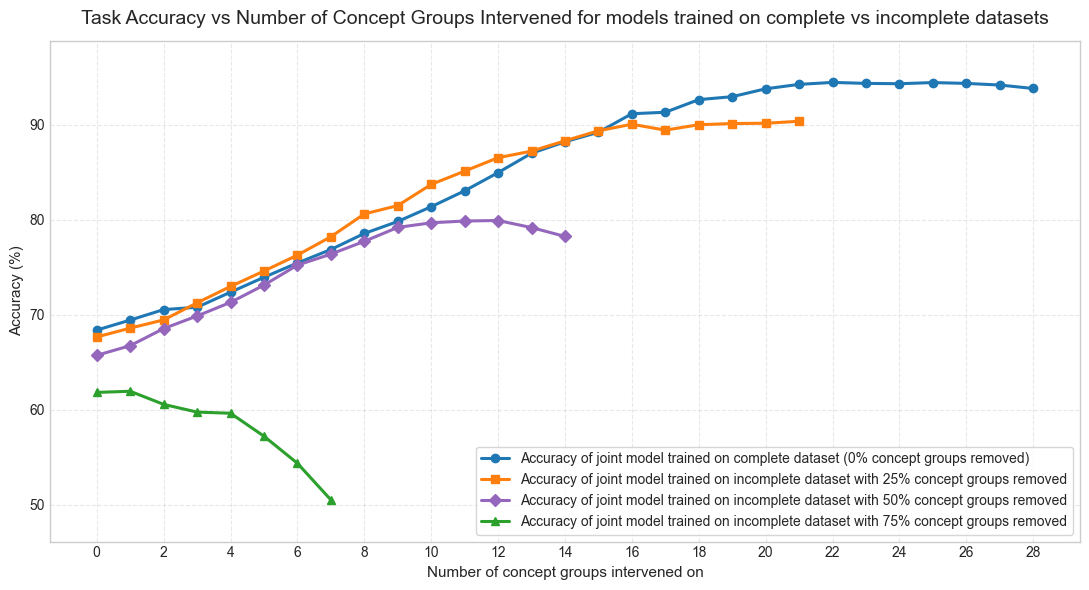

In [90]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

accuracies_joint_05 = []
accuracies_joint_075 = []
accuracies_joint_025 = []
accuracies_joint_0 = []

with open("intervention/joint_model_attr_weight_0.01_200_weight_sigmoid_range.txt", "r") as f:
    lines = f.readlines()
    for idx, line in enumerate(lines):
        if idx == 0:
            continue
        accuracy = line.strip().split(": ")[1]
        accuracy = float(accuracy)
        accuracies_joint_0.append(accuracy)
        

with open("intervention/joint_model_attr_weight_0.01_200_weight_sigmoid_incomplete_0.25_range", "r") as f:
    lines = f.readlines()
    for idx, line in enumerate(lines):
        if idx == 0:
            continue
        accuracy = line.strip().split(": ")[1]
        accuracy = float(accuracy)
        accuracies_joint_025.append(accuracy)
        

with open("intervention/joint_model_attr_weight_0.01_200_weight_sigmoid_incomplete_0.5_range", "r") as f:
    lines = f.readlines()
    for idx, line in enumerate(lines):
        if idx == 0:
            continue
        accuracy = line.strip().split(": ")[1]
        accuracy = float(accuracy)
        accuracies_joint_05.append(accuracy)

with open("intervention/joint_model_attr_weight_0.01_200_weight_sigmoid_incomplete_0.75_range", "r") as f:
    lines = f.readlines()
    for idx, line in enumerate(lines):
        if idx == 0:
            continue
        accuracy = line.strip().split(": ")[1]
        accuracy = float(accuracy)
        accuracies_joint_075.append(accuracy)
        
print(f"Length of 0.25 list: {len(accuracies_joint_025)}")
print(f"Length of 0.5 list: {len(accuracies_joint_05)}")
print(f"Length of 0.75 list: {len(accuracies_joint_075)}")
print(f"length complete concept dataset list: {len(accuracies_joint_0)}")

x_05 = list(range(len(accuracies_joint_05)))
x_075 = list(range(len(accuracies_joint_075)))
x_025 = list(range(len(accuracies_joint_025)))
x_0 = list(range(len(accuracies_joint_0)))

best_idx_0 = max(range(len(accuracies_joint_0)), key=lambda i: accuracies_joint_0[i])
best_acc_0 = accuracies_joint_0[best_idx_0]

best_idx_025 = max(range(len(accuracies_joint_025)), key=lambda i: accuracies_joint_025[i])
best_acc_025 = accuracies_joint_025[best_idx_025]

best_idx_05 = max(range(len(accuracies_joint_05)), key=lambda i: accuracies_joint_05[i])
best_acc_05 = accuracies_joint_05[best_idx_05]

best_idx_075 = max(range(len(accuracies_joint_075)), key=lambda i: accuracies_joint_075[i])
best_acc_075 = accuracies_joint_075[best_idx_075]

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    x_0,
    accuracies_joint_0,     
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#1f77b4",
    label=r"Accuracy of joint model trained on complete dataset (0% concept groups removed)",
)

ax.plot(
    x_025,
    accuracies_joint_025,
    marker="s",
    linewidth=2.2,
    markersize=6,
    color="#ff7f0e",
    label=r"Accuracy of joint model trained on incomplete dataset with 25% concept groups removed",
)



ax.plot(
    x_05,
    accuracies_joint_05,
    marker="D",
    linewidth=2.2,
    markersize=6,
    color="#9467bd",
    label=r"Accuracy of joint model trained on incomplete dataset with 50% concept groups removed",
)

ax.plot(
    x_075,
    accuracies_joint_075,
    marker="^",
    linewidth=2.2,
    markersize=6,
    color="#2ca02c",
    label=r"Accuracy of joint model trained on incomplete dataset with 75% concept groups removed",
)



ax.set_title(
    "Task Accuracy vs Number of Concept Groups Intervened for models trained on complete vs incomplete datasets",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Number of concept groups intervened on", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)

max_len = max(len(accuracies_joint_05), len(accuracies_joint_075), len(accuracies_joint_025), len(accuracies_joint_0))
ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune=None, nbins=min(20, max_len)))

y_min = min(min(accuracies_joint_05), min(accuracies_joint_075), min(accuracies_joint_025), min(accuracies_joint_0))
y_max = max(max(accuracies_joint_05), max(accuracies_joint_075), max(accuracies_joint_025), max(accuracies_joint_0))
pad = max((y_max - y_min) * 0.1, 0.5)
ax.set_ylim(y_min - pad, y_max + pad)

ax.grid(True, which="major", linestyle="--", alpha=0.45)
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

In [92]:
import pandas as pd

inference_dir = "inference/outputs/"
files = ["joint_model_attr_weight_0.01_200_weight_sigmoid.txt",
        "joint_model_attr_weight_0.01_200_weight_sigmoid_incomplete_0.25.txt", 
         "joint_model_attr_weight_0.01_200_weight_sigmoid_incomplete_0.5.txt",
         "joint_model_attr_weight_0.01_200_weight_sigmoid_incomplete_0.75.txt"
         ]
model_names = [
    "Joint (0% removed / complete)",
    "Joint (25% groups removed)",
    "Joint (50% groups removed)",
    "Joint (75% groups removed)"
]

def extract_info_from_file(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()
        task_accuracy_line = lines[1]
        attribute_accuracy_line = lines[4]
        task_accuracy = float(task_accuracy_line.strip().split(": ")[1])
        attribute_accuracy = float(attribute_accuracy_line.strip().split(": ")[1])
        return task_accuracy, attribute_accuracy
    
attr_accuracies = {}
task_accuracies = {}
attr_errors = {}
task_errors = {}

for i in range(len(files)):
    file_path = inference_dir + files[i]
    task_acc, attr_acc = extract_info_from_file(file_path)
    task_accuracies[model_names[i]] = task_acc
    attr_accuracies[model_names[i]] = attr_acc
    attr_errors[model_names[i]] = (100 - attr_acc)/100
    task_errors[model_names[i]] = (100 - task_acc)/100
    
    

df = pd.DataFrame({
    "Model": model_names,
    "Task Accuracy": [task_accuracies[name] for name in model_names],
    "Attribute Accuracy": [attr_accuracies[name] for name in model_names],
    "Task Error": [task_errors[name] for name in model_names],
    "Attribute Error": [attr_errors[name] for name in model_names]
})

paper_metrics = {"Model": "Original model from paper", "Task Error": 0.199, "Attribute Error": 0.031, 
                 "Task Accuracy": (1-0.199)*100, "Attribute Accuracy": (1-0.031)*100}

df.loc[len(df)] = paper_metrics
df_sliced = df[["Model", "Task Accuracy", "Attribute Accuracy"]]
df_sliced.head()


        

,Model,Task Accuracy,Attribute Accuracy
0,Joint (0% removed / complete),68.38108,92.72739
1,Joint (25% groups removed),67.65620,92.20817
2,Joint (50% groups removed),65.72316,90.71160
3,Joint (75% groups removed),61.82257,89.42749
4,Original model from paper,80.10000,96.90000
